# Preparación de Datos: Caso de Estudio La Laguna
Este cuaderno extrae, limpia y transforma los datos geoespaciales reales de San Cristóbal de La Laguna para generar una instancia válida para el Modelo de Decisión Heurístico (HDM) de optimización de recolección de residuos.

## 1. Importaciones y Configuración

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import warnings

# Configuración
warnings.filterwarnings('ignore') # Ocultar warnings visuales molestos de proyecciones futuras
ox.settings.use_cache = True
ox.settings.log_console = False

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


## 2. Preparación de los Conjuntos J e I

### 2.1 Conjunto J (Puntos de Recolección Potenciales)
Primero extraemos la red peatonal. Los nodos originales (esquinas) formarán nuestra base para el conjunto $J$.

In [2]:
# Definir la zona de estudio
lugar = "Plaza del Cristo, San Cristóbal de La Laguna, España"
distancia = 300 # metros de radio

print(f"Descargando grafo peatonal a {distancia}m de {lugar}...")
grafo = ox.graph_from_address(lugar, dist=distancia, network_type='walk')

# Convertir a tablas de datos
nodos, aristas = ox.graph_to_gdfs(grafo)

print(f"Nodos base encontrados (Esquinas J): {len(nodos)}")
print(f"Calles encontradas: {len(aristas)}")

# DATASETS DE PRUEBA:
print("Visualización de los nodos:")
print(nodos.head())
print("Visualización de las aristas:")
print(aristas.head())

Descargando grafo peatonal a 300m de Plaza del Cristo, San Cristóbal de La Laguna, España...
Nodos base encontrados (Esquinas J): 85
Calles encontradas: 206
Visualización de los nodos:
                   y          x  street_count highway  \
osmid                                                   
262190674  28.492838 -16.315614             4     NaN   
277358701  28.490148 -16.310915             4     NaN   
278693225  28.492205 -16.315805             4     NaN   
278934723  28.492729 -16.313947             4     NaN   
278934724  28.492305 -16.312446             3     NaN   

                             geometry  
osmid                                  
262190674  POINT (-16.31561 28.49284)  
277358701  POINT (-16.31092 28.49015)  
278693225  POINT (-16.31581 28.49221)  
278934723  POINT (-16.31395 28.49273)  
278934724  POINT (-16.31245 28.49231)  
Visualización de las aristas:
                               osmid lanes                               name  \
u         v           ke

**Problema:** En el grafo anterior hay segmentos de calle (líneas grises) muy largos sin puntos rojos. Obligar a un vecino a recorrer toda esa calle para tirar la basura es irreal.

**Solución Heurística:** Recorremos todas las calles. Si una calle mide más de 100 metros, calculamos puntos intermedios a lo largo de su geometría y los añadimos como nuevos contenedores potenciales al conjunto $J$.

In [3]:
DISTANCIA_MAXIMA_CALLE = 100 # metros
nuevos_nodos = []
id_nodo_artificial = 999000000 # Empezamos con IDs muy altos para no pisar los de OSM

print(f"Buscando calles con longitud mayor a {DISTANCIA_MAXIMA_CALLE}m...")

# Proyectamos las aristas a UTM (metros) temporalmente para medir la longitud real
aristas_utm = ox.project_gdf(aristas)

print("Ejemplo del DATASET PROCESADO (aristas proyectadas a UTM):")
print(aristas_utm.head())

Buscando calles con longitud mayor a 100m...
Ejemplo del DATASET PROCESADO (aristas proyectadas a UTM):
                               osmid lanes                               name  \
u         v           key                                                       
262190674 916214663   0     77960199     2  Avenida de la República Argentina   
          11085704169 0     78708045     1               Calle Quintín Benito   
          278693225   0    477531147   NaN                 Calle Juan de Vera   
          976280004   0    754718887     1               Calle Quintín Benito   
277358701 13132076305 0    126767784     1                                NaN   

                                highway  oneway  reversed  length  \
u         v           key                                           
262190674 916214663   0        tertiary   False     False  49.169   
          11085704169 0     residential   False      True  53.775   
          278693225   0     residential   False     

Se han inyectado 32 puntos artificiales.
Total puntos de recolección potenciales (J_final): 117


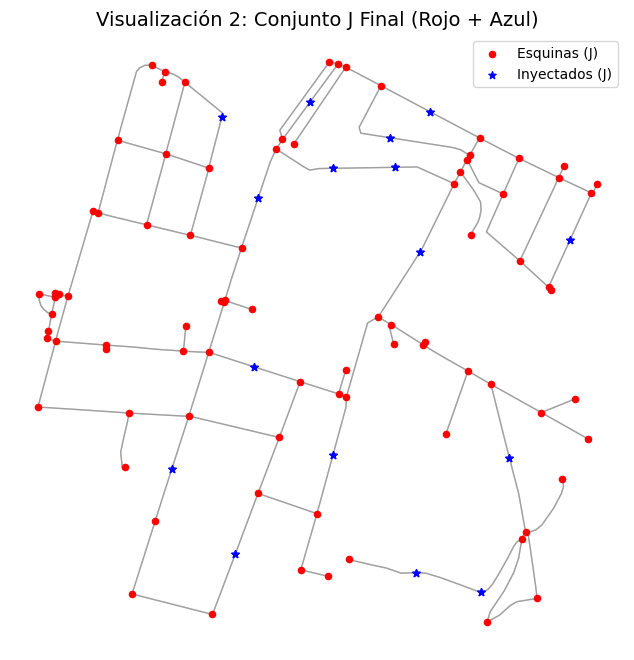

In [4]:
for index, fila in aristas_utm.iterrows():
    longitud = fila.geometry.length
    
    if longitud > DISTANCIA_MAXIMA_CALLE:
        # Calcular cuántos puntos extra necesitamos
        num_puntos_extra = int(longitud // DISTANCIA_MAXIMA_CALLE)
        distancia_entre_puntos = longitud / (num_puntos_extra + 1)
        
        # Generar los puntos a lo largo de la línea
        for i in range(1, num_puntos_extra + 1):
            distancia_actual = i * distancia_entre_puntos
            # La función interpolate nos da el punto exacto a 'x' metros del inicio de la calle
            punto_nuevo_utm = fila.geometry.interpolate(distancia_actual)
            
            nuevos_nodos.append({
                'osmid': id_nodo_artificial,
                'geometry': punto_nuevo_utm,
                'artificial': True
            })
            id_nodo_artificial += 1

# Si hemos creado nodos nuevos, los añadimos a nuestra tabla principal
if nuevos_nodos:
    # Convertimos los nuevos nodos a un DataFrame
    df_nuevos_nodos_utm = gpd.GeoDataFrame(nuevos_nodos, crs=aristas_utm.crs)
    
    # Los devolvemos a coordenadas geográficas (Lat/Lon)
    df_nuevos_nodos = df_nuevos_nodos_utm.to_crs(epsg=4326)
    df_nuevos_nodos.set_index('osmid', inplace=True)
    
    # Unimos los originales con los nuevos
    nodos_J_final = pd.concat([nodos, df_nuevos_nodos])
    print(f"Se han inyectado {len(nuevos_nodos)} puntos artificiales.")
else:
    nodos_J_final = nodos.copy()
    print("No hubo calles tan largas. No se inyectaron nodos.")

print(f"Total puntos de recolección potenciales (J_final): {len(nodos_J_final)}")

# Visualización 2: El grafo con los puntos inyectados en azul
fig, ax = plt.subplots(figsize=(8, 8))
aristas.plot(ax=ax, linewidth=1, edgecolor='gray', alpha=0.5)

# Pintamos los nodos originales en rojo
nodos.plot(ax=ax, markersize=20, color='red', label='Esquinas (J)', zorder=3)

# Pintamos los nuevos nodos artificiales en azul si existen
if nuevos_nodos:
    df_nuevos_nodos.plot(ax=ax, markersize=30, color='blue', marker='*', label='Inyectados (J)', zorder=4)

plt.title("Visualización 2: Conjunto J Final (Rojo + Azul)", fontsize=14)
plt.legend()
plt.axis('off')
plt.show()

### 2.2 Conjunto I (Puntos de Demanda)
Ahora descargamos las "huellas" (polígonos) de los edificios reales.
Para estimar la demanda poblacional ($h_i$) de forma realista, calcularemos el área en metros cuadrados de cada edificio y la multiplicaremos por su número de plantas estimado, asumiendo 1 habitante por cada 30 $m^2$ de superficie construida. El punto de origen de la demanda será el centroide geométrico del polígono.

In [5]:
print(f"Descargando polígonos de edificios a {distancia}m de {lugar}...")

# 1. Descarga inicial
edificios = ox.features_from_address(lugar, tags={'building': True}, dist=distancia)
edificios = edificios[edificios.geometry.type == 'Polygon'].copy()

# 2. FILTRADO INTELIGENTE: Eliminar estructuras que no generan basura residencial
tipos_a_ignorar = ['garage', 'garages', 'roof', 'shed', 'ruins', 'greenhouse']
# Si la columna 'building' existe, filtramos. Si no, seguimos.
if 'building' in edificios.columns:
    edificios = edificios[~edificios['building'].isin(tipos_a_ignorar)].copy()

# Proyectar a UTM para cálculos métricos
edificios_utm = ox.project_gdf(edificios)

# DATASET DE PRUEBA:
print("Ejemplo del DATASET DE EDIFICIOS ORIGINAL (en Lat/Lon):")
print(edificios.head())

Descargando polígonos de edificios a 300m de Plaza del Cristo, San Cristóbal de La Laguna, España...
Ejemplo del DATASET DE EDIFICIOS ORIGINAL (en Lat/Lon):
                                 amenity  \
element_type osmid                         
way          78313523        marketplace   
             79544621                NaN   
             83873879   place_of_worship   
             83873890   place_of_worship   
             119212449               NaN   

                                                                 geometry  \
element_type osmid                                                          
way          78313523   POLYGON ((-16.31330 28.49270, -16.31323 28.492...   
             79544621   POLYGON ((-16.31420 28.49280, -16.31409 28.492...   
             83873879   POLYGON ((-16.31550 28.49288, -16.31549 28.492...   
             83873890   POLYGON ((-16.31396 28.49283, -16.31398 28.492...   
             119212449  POLYGON ((-16.31246 28.49204, -16.31230 28.492..

In [6]:
# Calcular Área y Centroide exacto en metros
edificios_utm['area_m2'] = edificios_utm.geometry.area
edificios_utm['centroide_utm'] = edificios_utm.geometry.centroid

# Mostramos algunos datos para verificar
print("Ejemplo del DATASET DE EDIFICIOS PROCESADO (en UTM):")
print(edificios_utm[['area_m2', 'centroide_utm']].head())

Ejemplo del DATASET DE EDIFICIOS PROCESADO (en UTM):
                            area_m2                   centroide_utm
element_type osmid                                                 
way          78313523   2042.025867  POINT (371446.058 3152517.033)
             79544621    200.838541  POINT (371377.093 3152507.322)
             83873879     25.389941  POINT (371241.961 3152510.826)
             83873890     43.191028  POINT (371388.629 3152499.405)
             119212449   546.714763  POINT (371547.889 3152397.715)


In [7]:
# 3. IMPUTACIÓN INTELIGENTE DE PLANTAS (Tu idea)
if 'building:levels' in edificios_utm.columns:
    edificios_utm['plantas_reales'] = pd.to_numeric(edificios_utm['building:levels'], errors='coerce')
    
    medias_por_tipo = edificios_utm.groupby('building')['plantas_reales'].transform('mean')
    
    # Rellenar los NaN primero con la media de su tipo. 
    # Si su tipo tampoco tiene media (ej. solo hay un edificio raro y no tiene plantas), 
    # usamos la media global de toda la zona extraída.
    media_global = edificios_utm['plantas_reales'].mean()
    
    edificios_utm['plantas'] = edificios_utm['plantas_reales'].fillna(medias_por_tipo).fillna(media_global)
    edificios_utm['plantas'] = edificios_utm['plantas'].round().astype(int)
else:
    edificios_utm['plantas'] = 2

print("Ejemplo del DATASET DE EDIFICIOS CON PLANTAS ESTIMADAS:")
print(edificios_utm[['building', 'plantas_reales', 'plantas']].head())

Ejemplo del DATASET DE EDIFICIOS CON PLANTAS ESTIMADAS:
                       building  plantas_reales  plantas
element_type osmid                                      
way          78313523      tent             NaN        2
             79544621    public             3.0        3
             83873879    church             NaN        2
             83873890    church             1.0        1
             119212449      yes             2.0        2


In [8]:
# 4. Cálculo de Habitantes
edificios_utm['habitantes'] = ((edificios_utm['area_m2'] * edificios_utm['plantas']) / 30).astype(int)
edificios_utm.loc[edificios_utm['habitantes'] < 1, 'habitantes'] = 1

In [9]:
# 5. Volver a Lat/Lon y preparar el dataset enriquecido
edificios['centroide'] = edificios_utm['centroide_utm'].to_crs(epsg=4326)
edificios['area_m2'] = edificios_utm['area_m2'].round(2)
edificios['plantas'] = edificios_utm['plantas']
edificios['habitantes'] = edificios_utm['habitantes']

# Extraer el nombre de la calle si existe, si no, poner "Desconocida"
if 'addr:street' in edificios.columns:
    edificios['calle'] = edificios['addr:street'].fillna('Desconocida')
else:
    edificios['calle'] = 'Desconocida'

# TABLA FINAL ENRIQUECIDA (I)
nodos_I_final = edificios[['centroide', 'building', 'calle', 'area_m2', 'plantas', 'habitantes', 'geometry']].copy()

print(f"Total puntos de demanda extraídos (Conjunto I): {len(nodos_I_final)}")
print(f"Población total estimada en la zona: {nodos_I_final['habitantes'].sum()} habitantes")

# Mostrar las 5 primeras filas para ver cómo ha quedado nuestro dataset enriquecido
nodos_I_final.head()

Total puntos de demanda extraídos (Conjunto I): 337
Población total estimada en la zona: 9235 habitantes


centroide building        calle  \
element_type osmid                                                         
way          78313523   POINT (-16.31344 28.49298)     tent  Desconocida   
             79544621   POINT (-16.31414 28.49288)   public  Desconocida   
             83873879   POINT (-16.31552 28.49290)   church  Desconocida   
             83873890   POINT (-16.31402 28.49281)   church  Desconocida   
             119212449  POINT (-16.31238 28.49191)      yes  Desconocida   

                        area_m2  plantas  habitantes  \
element_type osmid                                     
way          78313523   2042.03        2         136   
             79544621    200.84        3          20   
             83873879     25.39        2           1   
             83873890     43.19        1           1   
             119212449   546.71        2          36   

                                                                 geometry  
element_type osmid                                                         
way          78313523   POLYGON ((-16.31330 28.49270, -16.31323 28.492...  
             79544621   POLYGON ((-16.31420 28.49280, -16.31409 28.492...  
             83873879   POLYGON ((-16.31550 28.49288, -16.31549 28.492...  
             83873890   POLYGON ((-16.31396 28.49283, -16.31398 28.492...  
             119212449  POLYGON ((-16.31246 28.49204, -16.31230 28.492...

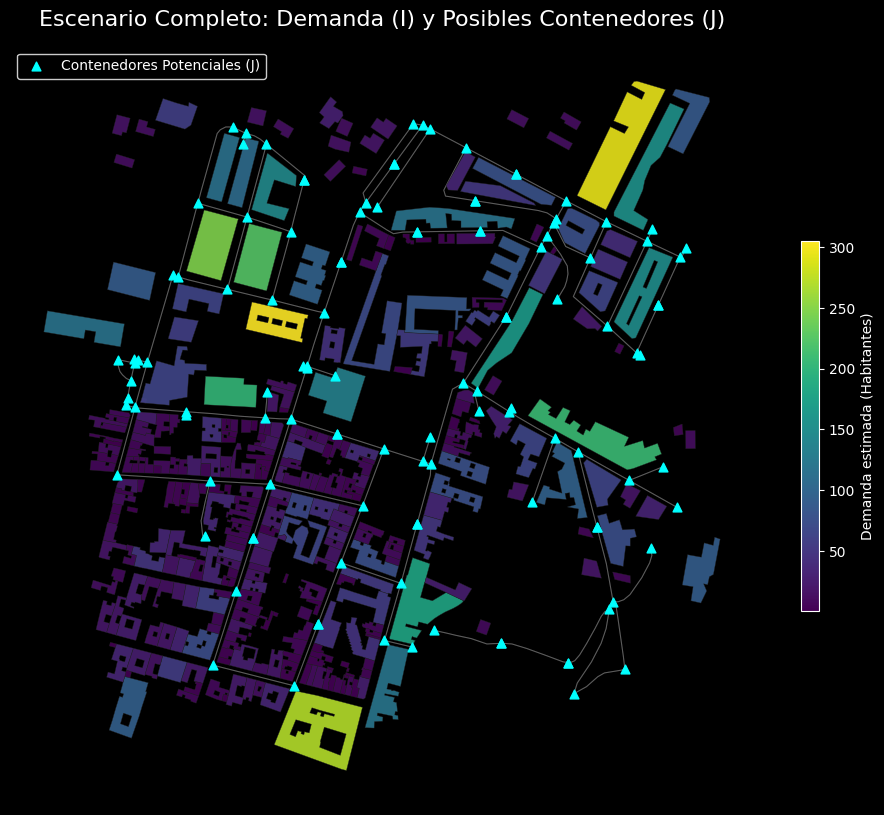

In [11]:
# Activar el tema oscuro
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(12, 12)) # Lo hacemos un poco más grande para verlo mejor

# 1. Calles (Fondo tenue)
aristas.plot(ax=ax, linewidth=0.8, edgecolor='white', alpha=0.2, zorder=1)

# 2. Conjunto I: Edificios (Mapa de Calor de Demanda)
nodos_I_final.set_geometry('geometry').plot(
    ax=ax, 
    column='habitantes', 
    cmap='viridis', 
    legend=True, 
    legend_kwds={'label': "Demanda estimada (Habitantes)", 'shrink': 0.4},
    alpha=0.9, 
    edgecolor='#222222', 
    linewidth=0.3,
    zorder=2
)

# 3. Conjunto J: Puntos de Recolección Potenciales
nodos_J_final.plot(
    ax=ax, 
    color='cyan', 
    marker='^', 
    markersize=40, 
    label='Contenedores Potenciales (J)', 
    zorder=3
)

plt.title("Escenario Completo: Demanda (I) y Posibles Contenedores (J)", fontsize=16, pad=15)
plt.legend(loc='upper left', frameon=True, facecolor='black', edgecolor='white')
plt.axis('off')

plt.show()

# Desactivar tema oscuro
plt.style.use('default')

## 3. Matriz de Distancias por Red ($d_{ij}$)

Para calcular las distancias reales caminando, proyectaremos las coordenadas de los edificios ($I$) y contenedores ($J$) al nodo peatonal más cercano del grafo. Luego, usaremos el algoritmo de Dijkstra para encontrar la ruta más corta. 

Para optimizar la memoria (Matriz Dispersa), solo guardaremos aquellas conexiones cuya distancia sea menor a un radio máximo de viabilidad (ej. 400 metros).

In [22]:
import numpy as np
import networkx as nx

RADIO_MAXIMO_CUBIERTO = 350 # metros máximos

print(f"1. Enganchando edificios y contenedores a la red de calles...")
I_x = nodos_I_final['centroide'].apply(lambda p: p.x).values
I_y = nodos_I_final['centroide'].apply(lambda p: p.y).values

J_x = nodos_J_final.geometry.apply(lambda p: p.x).values
J_y = nodos_J_final.geometry.apply(lambda p: p.y).values

# Evita el error de scikit-learn proyectando el grafo y los puntos a CRS métrico
grafo = ox.project_graph(grafo)
crs_grafo = ox.graph_to_gdfs(grafo, nodes=True, edges=False).crs

I_centroides_proj = gpd.GeoSeries(nodos_I_final['centroide'], crs="EPSG:4326").to_crs(crs_grafo)
J_puntos_proj = nodos_J_final.geometry.to_crs(crs_grafo)

I_x, I_y = I_centroides_proj.x.values, I_centroides_proj.y.values
J_x, J_y = J_puntos_proj.x.values, J_puntos_proj.y.values

1. Enganchando edificios y contenedores a la red de calles...


In [23]:
def _nearest_nodes_numpy(G, X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)

    node_ids = []
    node_x = []
    node_y = []
    for nid, data in G.nodes(data=True):
        node_ids.append(nid)
        node_x.append(data["x"])
        node_y.append(data["y"])

    node_ids = np.array(node_ids, dtype=object)
    node_x = np.array(node_x, dtype=float)
    node_y = np.array(node_y, dtype=float)

    nearest = []
    for xq, yq in zip(X, Y):
        d2 = (node_x - xq) ** 2 + (node_y - yq) ** 2
        nearest.append(node_ids[np.argmin(d2)])
    return np.array(nearest, dtype=object)

ox.distance.nearest_nodes = _nearest_nodes_numpy
nodos_I_final['nodo_red_cercano'] = ox.distance.nearest_nodes(grafo, I_x, I_y)
nodos_J_final['nodo_red_cercano'] = ox.distance.nearest_nodes(grafo, J_x, J_y)

print(nodos_I_final[['centroide', 'nodo_red_cercano']].head())
print(nodos_J_final[['geometry', 'nodo_red_cercano']].head())

                                         centroide nodo_red_cercano
element_type osmid                                                 
way          78313523   POINT (-16.31344 28.49298)      10166910098
             79544621   POINT (-16.31414 28.49288)        923052566
             83873879   POINT (-16.31552 28.49290)        262190674
             83873890   POINT (-16.31402 28.49281)        278934723
             119212449  POINT (-16.31238 28.49191)        278934724
                             geometry nodo_red_cercano
osmid                                                 
262190674  POINT (-16.31561 28.49284)        262190674
277358701  POINT (-16.31092 28.49015)        277358701
278693225  POINT (-16.31581 28.49221)        278693225
278934723  POINT (-16.31395 28.49273)        278934723
278934724  POINT (-16.31245 28.49231)        278934724


In [24]:
print(f"2. Calculando rutas viables (Cutoff = {RADIO_MAXIMO_CUBIERTO}m)...")
distancias_dij = {}
conexiones_guardadas = 0
nodos_huerfanos = 0

2. Calculando rutas viables (Cutoff = 350m)...


In [25]:
for i_id, i_row in nodos_I_final.iterrows():
    origen = i_row['nodo_red_cercano']
    distancias_dij[i_id] = {}
    
    try:
        # Devuelve un diccionario con {nodo_destino: distancia_en_metros}
        distancias_desde_origen = nx.single_source_dijkstra_path_length(
            grafo, 
            origen, 
            cutoff=RADIO_MAXIMO_CUBIERTO, 
            weight='length'
        )
        
        # Iteramos sobre todos los contenedores J para ver si han sido alcanzados
        for j_id, j_row in nodos_J_final.iterrows():
            destino = j_row['nodo_red_cercano']
            
            # Si el destino está en las distancias calculadas, es que está a <= 400m
            if destino in distancias_desde_origen:
                dist_red = distancias_desde_origen[destino]
                distancias_dij[i_id][j_id] = round(dist_red, 2)
                conexiones_guardadas += 1
                
    except nx.NetworkXNoPath:
        pass # No se encontró ruta a ninguna parte (nodo aislado en el mapa)
    
    # CONTROL DE HUÉRFANOS: Si este edificio no alcanzó ningún contenedor J
    if len(distancias_dij[i_id]) == 0:
        nodos_huerfanos += 1

print("\n--- RESUMEN DE LA MATRIZ DISPERSA ---")
print(f"Edificios procesados (I): {len(nodos_I_final)}")
print(f"Contenedores procesados (J): {len(nodos_J_final)}")
print(f"Conexiones válidas almacenadas: {conexiones_guardadas}")

if nodos_huerfanos > 0:
    print(f"⚠️ ¡ALERTA CRÍTICA! Hay {nodos_huerfanos} edificios que NO tienen contenedores a menos de {RADIO_MAXIMO_CUBIERTO}m.")
    print("   -> Gurobi devolverá 'Infactible'. Debes aumentar el radio o inyectar más contenedores J.")
else:
    print(f"✅ Cobertura perfecta. Todos los edificios tienen al menos un contenedor viable.")

# Muestra el diccionario de distancias del primer edificio
primer_edificio_id = nodos_I_final.index[0]
print(f"\nDistancias desde el edificio {primer_edificio_id}:")
print(distancias_dij[primer_edificio_id])


--- RESUMEN DE LA MATRIZ DISPERSA ---
Edificios procesados (I): 337
Contenedores procesados (J): 117
Conexiones válidas almacenadas: 12839
✅ Cobertura perfecta. Todos los edificios tienen al menos un contenedor viable.

Distancias desde el edificio ('way', 78313523):
{262190674: 251.48, 278693225: 320.0, 278934723: 88.13, 278934724: 242.19, 278936705: 317.51, 278936706: 190.41, 278937841: 159.15, 278937842: 253.82, 278938315: 276.94, 281114406: 201.13, 281114420: 336.84, 916214663: 300.65, 919596737: 320.78, 919596738: 246.42, 919596740: 89.31, 919596745: 219.21, 919596746: 267.44, 919596747: 193.33, 919596748: 331.86, 919596751: 252.18, 919596762: 145.33, 923052558: 114.96, 923052566: 142.26, 923709796: 312.81, 923709808: 321.92, 923709821: 313.14, 976279897: 268.82, 976279921: 305.64, 976279981: 287.05, 976280004: 261.01, 976280023: 314.8, 976280085: 310.71, 2016881660: 212.82, 9446917866: 233.24, 9446963326: 36.12, 9446963327: 31.9, 10166910097: 30.4, 10166910098: 0, 10166910099: 2

## Definición de Parametros para del Modelo

Aquí centralizamos TODOS los parámetros del modelo matemático.
Modificar un valor aquí se propaga automáticamente al JSON y al solver.

In [26]:
TIPOS_RESIDUO = {
    0: "organica",
    1: "resto",
    2: "reciclable",
    3: "peligrosos"
}

# generación per cápita diaria total (kg/persona/día)
G_PERCAPITA_DIA = 1.32  # kg/persona/día

# Proporciones por tipo (α_k): tomadas del artículo
PROPORCION_RESIDUO = {
    0: 0.5012,   # Orgánica:    50.12%
    1: 0.0791,   # Resto:        7.91%
    2: 0.3885,   # Reciclable:  38.85%
    3: 0.0312    # Peligrosos:   3.12%
}

# Verificación: las proporciones deben sumar 1.0
assert abs(sum(PROPORCION_RESIDUO.values()) - 1.0) < 1e-6, \
    "ERROR: Las proporciones no suman 1.0"

# c_k: coste unitario de un contenedor tipo k (€)
# Adaptado a precios reales España (contenedores estándar 240L-1100L).
COSTE_CONTENEDOR = {
    0: 350,   # Orgánica:   contenedor marrón, mayor limpieza requerida
    1: 300,   # Resto:      contenedor gris estándar
    2: 250,   # Reciclable: contenedor amarillo/azul, menor mantenimiento
    3: 500    # Peligrosos: contenedor especial, homologación requerida
}

# Q_k: capacidad física de un contenedor tipo k (kg)
CAPACIDAD_CONTENEDOR = {
    0: 120, 
    1: 120,   
    2: 120, 
    3: 120
}

RADIO_COBERTURA = {
    0: 150,   # Orgánica:   150m (generación diaria, olor → distancia corta)
    1: 150,   # Resto:      150m (mismo hábito de uso que orgánica)
    2: 250,   # Reciclable: 250m (menor frecuencia, toleran más distancia)
    3: 350    # Peligrosos: 350m (muy baja frecuencia, aceptan distancia mayor)
}

COSTE_APERTURA_PUNTO = 4000.0   # €
MAX_CONTENEDORES_POR_PUNTO = 8
DISTANCIA_MINIMA_NIMBY = 10.0   # metros




COSTE_PENALIZACION = 500.0   # € (escala española)


print("=" * 58)
print("  PARÁMETROS DEL MODELO — CASO LA LAGUNA")
print("=" * 58)
print(f"\n{'Tipo':<14} {'c_k (€)':>8} {'Q_k (kg)':>10} {'r_k (m)':>9}")
print("-" * 45)
for k, nombre in TIPOS_RESIDUO.items():
    print(f"  {nombre:<12} {COSTE_CONTENEDOR[k]:>8} "
          f"{CAPACIDAD_CONTENEDOR[k]:>10} {RADIO_COBERTURA[k]:>9}")
 
print(f"\n  g per cápita/día : {G_PERCAPITA_DIA} kg/persona/día")
print(f"  Coste apertura   : {COSTE_APERTURA_PUNTO} €")
print(f"  Máx. conten./J   : {MAX_CONTENEDORES_POR_PUNTO}")
print(f"  NIMBY r_0        : {DISTANCIA_MINIMA_NIMBY} m")
print(f"  Penalización τ_j : {COSTE_PENALIZACION} €")

  PARÁMETROS DEL MODELO — CASO LA LAGUNA

Tipo            c_k (€)   Q_k (kg)   r_k (m)
---------------------------------------------
  organica          350        120       150
  resto             300        120       150
  reciclable        250        120       250
  peligrosos        500        120       350

  g per cápita/día : 1.32 kg/persona/día
  Coste apertura   : 4000.0 €
  Máx. conten./J   : 8
  NIMBY r_0        : 10.0 m
  Penalización τ_j : 500.0 €


In [31]:
print("\n" + "=" * 58)
print("  DEMANDA q_i^k = h_i × g × α_k  (kg/día por edificio)")
print("=" * 58)
 
for k, nombre in TIPOS_RESIDUO.items():
    col = f"demanda_{nombre}"
    nodos_I_final[col] = (
        nodos_I_final['habitantes']
        * G_PERCAPITA_DIA
        * PROPORCION_RESIDUO[k]
    ).round(4)
 
print(f"\n{'Tipo':<14} {'Media (kg)':>11} {'Máx (kg)':>10} {'Total zona (kg)':>17}")
print("-" * 56)
for k, nombre in TIPOS_RESIDUO.items():
    col = f"demanda_{nombre}"
    media  = nodos_I_final[col].mean()
    maximo = nodos_I_final[col].max()
    total  = nodos_I_final[col].sum()
    print(f"  {nombre:<12} {media:>11.2f} {maximo:>10.2f} {total:>17.2f}")
 
print(f"\n  Edificios (I)    : {len(nodos_I_final)}")
print(f"  Población total  : {nodos_I_final['habitantes'].sum()} habitantes")
print("\n✅ Demanda q_i^k calculada y añadida a nodos_I_final.")
 


  DEMANDA q_i^k = h_i × g × α_k  (kg/día por edificio)

Tipo            Media (kg)   Máx (kg)   Total zona (kg)
--------------------------------------------------------
  organica           18.13     201.78           6109.73
  resto               2.86      31.85            964.24
  reciclable         14.05     156.41           4735.89
  peligrosos          1.13      12.56            380.34

  Edificios (I)    : 337
  Población total  : 9235 habitantes

✅ Demanda q_i^k calculada y añadida a nodos_I_final.


## Exportar JSON para el Solver
Finalmente, exportamos toda la información a un archivo JSON con la estructura requerida por el solver de optimización.

In [32]:
# ==============================================================================
# EXPORTACIÓN DE LA INSTANCIA A JSON
# ==============================================================================
# Secciones del JSON:
#   1. meta          -> información del caso de estudio
#   2. parametros    -> todos los escalares del modelo (C_j, Q_k, r_k, ...)
#   3. conjunto_K    -> tipos de residuo
#   4. conjunto_I    -> edificios con su demanda q_i^k ya calculada
#   5. conjunto_J    -> puntos candidatos a contenedor
#   6. distancias    -> matriz dispersa d_ij en metros
# ==============================================================================

import json
import os
from datetime import datetime

# ── 1. CARPETA DE DESTINO ──────────────────────────────────────────────────────
OUTPUT_DIR  = "data/processed"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "instancia_laguna.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [33]:
# ── 2. SERIALIZAR CONJUNTO I ───────────────────────────────────────────────────
print("Serializando conjunto I (edificios)...")

lista_I = []
for i_id, row in nodos_I_final.iterrows():

    centroide = row['centroide']

    # q_i^k ya calculado en la celda anterior como columnas del DataFrame
    demanda = {
        str(k): round(row[f"demanda_{nombre}"], 4)
        for k, nombre in TIPOS_RESIDUO.items()
    }

    lista_I.append({
        "id":         str(i_id),
        "lon":        round(centroide.x, 7),
        "lat":        round(centroide.y, 7),
        "habitantes": int(row['habitantes']),
        "tipo_edif":  str(row.get('building', 'unknown')),
        "demanda":    demanda
    })

print(f"  -> {len(lista_I)} edificios serializados")

Serializando conjunto I (edificios)...
  -> 337 edificios serializados


In [34]:
# ── 3. SERIALIZAR CONJUNTO J ───────────────────────────────────────────────────
print("Serializando conjunto J (contenedores potenciales)...")

lista_J = []
for j_id, row in nodos_J_final.iterrows():

    punto = row['geometry']

    lista_J.append({
        "id":         str(j_id),
        "lon":        round(punto.x, 7),
        "lat":        round(punto.y, 7),
        "artificial": bool(row.get('artificial', False))
    })

print(f"  -> {len(lista_J)} contenedores serializados")

Serializando conjunto J (contenedores potenciales)...
  -> 117 contenedores serializados


In [35]:
# ── 4. SERIALIZAR MATRIZ DISPERSA d_ij ────────────────────────────────────────
# JSON solo admite strings como claves de diccionario -> convertimos todos los IDs.
# Un par (i,j) ausente significa d_ij > radio -> el solver no puede asignarlo.
print("Serializando matriz dispersa d_ij...")

distancias_serial = {
    str(i_id): {str(j_id): dist for j_id, dist in vecinos.items()}
    for i_id, vecinos in distancias_dij.items()
}

total_conexiones = sum(len(v) for v in distancias_serial.values())
densidad         = total_conexiones / (len(lista_I) * len(lista_J)) * 100

print(f"  -> {total_conexiones} conexiones ({densidad:.1f}% del total posible)")

Serializando matriz dispersa d_ij...
  -> 12839 conexiones (32.6% del total posible)


In [36]:
# ── 5. ENSAMBLAR EL JSON ───────────────────────────────────────────────────────
instancia = {

    "meta": {
        "caso_estudio":     "San Cristobal de La Laguna - Plaza del Cristo",
        "radio_osm_metros": 300,
        "radio_dij_metros": RADIO_MAXIMO_CUBIERTO,
        "fecha_generacion": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "referencia":       "Li et al. (2026), Waste Management 209, 115211",
        "n_edificios":      len(lista_I),
        "n_contenedores":   len(lista_J),
        "n_tipos_residuo":  len(TIPOS_RESIDUO),
        "poblacion_total":  int(nodos_I_final['habitantes'].sum()),
        "conexiones_dij":   total_conexiones
    },

    "parametros": {
        "C_j":             COSTE_APERTURA_PUNTO,
        "N_j":             MAX_CONTENEDORES_POR_PUNTO,
        "r_0":             DISTANCIA_MINIMA_NIMBY,
        "g_percapita_dia": G_PERCAPITA_DIA,
        "tau_j":           COSTE_PENALIZACION,
        "c_k":     {str(k): v for k, v in COSTE_CONTENEDOR.items()},
        "Q_k":     {str(k): v for k, v in CAPACIDAD_CONTENEDOR.items()},
        "r_k":     {str(k): v for k, v in RADIO_COBERTURA.items()},
        "alpha_k": {str(k): v for k, v in PROPORCION_RESIDUO.items()}
    },

    "conjunto_K":    {str(k): nombre for k, nombre in TIPOS_RESIDUO.items()},
    "conjunto_I":    lista_I,
    "conjunto_J":    lista_J,
    "distancias_dij": distancias_serial
}

In [37]:
# ── 6. ESCRIBIR A DISCO ────────────────────────────────────────────────────────
print(f"\nEscribiendo en '{OUTPUT_PATH}'...")

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(instancia, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(OUTPUT_PATH) / 1024

# ── 7. VERIFICACION DE INTEGRIDAD ─────────────────────────────────────────────
with open(OUTPUT_PATH, 'r', encoding='utf-8') as f:
    check = json.load(f)

assert len(check['conjunto_I'])     == len(lista_I), "ERROR: conjunto I corrupto"
assert len(check['conjunto_J'])     == len(lista_J), "ERROR: conjunto J corrupto"
assert len(check['distancias_dij']) == len(lista_I), "ERROR: matriz d_ij corrupta"

# ── 8. RESUMEN FINAL ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  INSTANCIA GENERADA Y VERIFICADA CORRECTAMENTE")
print("=" * 55)
print(f"  Archivo          : {OUTPUT_PATH}")
print(f"  Tamano           : {size_kb:.1f} KB")
print(f"  Edificios  (I)   : {check['meta']['n_edificios']}")
print(f"  Contenedores (J) : {check['meta']['n_contenedores']}")
print(f"  Poblacion total  : {check['meta']['poblacion_total']} hab.")
print(f"  Conexiones d_ij  : {check['meta']['conexiones_dij']}")
print(f"  Densidad matriz  : {densidad:.1f}%")
print("=" * 55)
print("\n-> Proximo paso: 02_modelo_exacto.ipynb (Gurobi)")


Escribiendo en 'data/processed/instancia_laguna.json'...

  INSTANCIA GENERADA Y VERIFICADA CORRECTAMENTE
  Archivo          : data/processed/instancia_laguna.json
  Tamano           : 450.2 KB
  Edificios  (I)   : 337
  Contenedores (J) : 117
  Poblacion total  : 9235 hab.
  Conexiones d_ij  : 12839
  Densidad matriz  : 32.6%

-> Proximo paso: 02_modelo_exacto.ipynb (Gurobi)
